# Blue Archive ガチャシミュレーション — 関数型リファクタリング版

この版では、次の制約を満たすように設計しています。

- 関数内でグローバル変数を参照しない
- 関数内でグローバル変数を書き換えない
- `State` を直接変更しない
- すべての状態変更は、新しい `State` を `return` して表現する
- 乱数生成器も関数へ明示的に渡す
- 終了条件・切替条件も関数として明示的に渡す

そのため、各関数の入力と出力を追えば処理全体をレビューできます。


In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from enum import Enum, auto
from typing import Callable
import random
import statistics

import matplotlib.pyplot as plt


## 1. 設定・状態・抽選結果

In [2]:
class GachaSystem(Enum):
    NEW = auto()
    OLD = auto()


class Banner(Enum):
    PU1 = auto()
    PU2 = auto()


class Draw(Enum):
    STAR1 = auto()
    STAR2 = auto()
    STAR3_OTHER = auto()
    PU1 = auto()
    PU2 = auto()


@dataclass(frozen=True)
class Config:
    system: GachaSystem = GachaSystem.NEW

    pickup_rate: float = 0.007
    other_pickup_rate: float = 0.00022115
    star3_rate: float = 0.03
    star2_or_higher_rate: float = 0.215

    initial_charge: int = 0
    initial_banner: Banner = Banner.PU1
    pulls_per_batch: int = 10

    charge_100_target_rate: float = 0.5
    charge_100_other_pickup_rate: float = 0.0
    charge_100: int = 100
    charge_200: int = 200

    # 旧方式: 200ポイントごとに対象PUを交換
    old_ceiling_points: int = 200

    def __post_init__(self) -> None:
        probabilities = (
            self.pickup_rate,
            self.other_pickup_rate,
            self.star3_rate,
            self.star2_or_higher_rate,
            self.charge_100_target_rate,
            self.charge_100_other_pickup_rate,
        )

        if not all(0.0 <= value <= 1.0 for value in probabilities):
            raise ValueError("All probabilities must be between 0 and 1.")

        if self.pickup_rate + self.other_pickup_rate > self.star3_rate:
            raise ValueError(
                "pickup_rate + other_pickup_rate must not exceed star3_rate."
            )

        if self.star3_rate > self.star2_or_higher_rate:
            raise ValueError(
                "star3_rate must not exceed star2_or_higher_rate."
            )

        if (
            self.charge_100_target_rate
            + self.charge_100_other_pickup_rate
            > 1.0
        ):
            raise ValueError(
                "charge_100_target_rate + "
                "charge_100_other_pickup_rate must not exceed 1."
            )

        if not 0 <= self.initial_charge < self.charge_200:
            raise ValueError(
                "initial_charge must satisfy 0 <= initial_charge < charge_200."
            )

        if self.pulls_per_batch <= 0:
            raise ValueError("pulls_per_batch must be positive.")

        if self.old_ceiling_points <= 0:
            raise ValueError("old_ceiling_points must be positive.")


@dataclass(frozen=True)
class State:
    pulls: int
    batches: int
    charge: int
    banner: Banner

    pu1: int
    pu2: int
    star3: int

    pu1_banner_pulls: int
    pu2_banner_pulls: int


@dataclass(frozen=True)
class TrialResult:
    state: State
    seed: int


## 2. 初期状態

In [3]:
def create_initial_state(config: Config) -> State:
    return State(
        pulls=0,
        batches=0,
        charge=config.initial_charge,
        banner=config.initial_banner,
        pu1=0,
        pu2=0,
        star3=0,
        pu1_banner_pulls=0,
        pu2_banner_pulls=0,
    )


## 3. 抽選ロジック

In [4]:
def target_draw(banner: Banner) -> Draw:
    if banner is Banner.PU1:
        return Draw.PU1
    return Draw.PU2


def other_pickup_draw(banner: Banner) -> Draw:
    if banner is Banner.PU1:
        return Draw.PU2
    return Draw.PU1


def draw_normal(
    config: Config,
    banner: Banner,
    rng: random.Random,
) -> Draw:
    random_value = rng.random()

    if random_value < config.pickup_rate:
        return target_draw(banner)

    if random_value < config.pickup_rate + config.other_pickup_rate:
        return other_pickup_draw(banner)

    if random_value < config.star3_rate:
        return Draw.STAR3_OTHER

    if random_value < config.star2_or_higher_rate:
        return Draw.STAR2

    return Draw.STAR1


def draw_charge_100(
    config: Config,
    banner: Banner,
    rng: random.Random,
) -> Draw:
    random_value = rng.random()

    if random_value < config.charge_100_target_rate:
        return target_draw(banner)

    other_pickup_upper = (
        config.charge_100_target_rate
        + config.charge_100_other_pickup_rate
    )

    if random_value < other_pickup_upper:
        return other_pickup_draw(banner)

    return Draw.STAR3_OTHER


def draw_one(
    config: Config,
    state: State,
    rng: random.Random,
) -> Draw:
    if config.system is GachaSystem.OLD:
        return draw_normal(
            config=config,
            banner=state.banner,
            rng=rng,
        )

    next_charge = state.charge + 1

    if next_charge == config.charge_200:
        return target_draw(state.banner)

    if next_charge == config.charge_100:
        return draw_charge_100(
            config=config,
            banner=state.banner,
            rng=rng,
        )

    return draw_normal(
        config=config,
        banner=state.banner,
        rng=rng,
    )


## 4. 抽選結果を新しい状態へ変換

In [5]:
def is_star3(result: Draw) -> bool:
    return result in {
        Draw.STAR3_OTHER,
        Draw.PU1,
        Draw.PU2,
    }


def is_current_banner_pickup(
    banner: Banner,
    result: Draw,
) -> bool:
    return (
        banner is Banner.PU1
        and result is Draw.PU1
    ) or (
        banner is Banner.PU2
        and result is Draw.PU2
    )


def apply_draw(
    config: Config,
    state: State,
    result: Draw,
) -> State:
    next_charge = state.charge + 1

    if (
        config.system is GachaSystem.NEW
        and is_current_banner_pickup(state.banner, result)
    ):
        next_charge = 0

    return replace(
        state,
        pulls=state.pulls + 1,
        charge=next_charge,
        pu1=state.pu1 + int(result is Draw.PU1),
        pu2=state.pu2 + int(result is Draw.PU2),
        star3=state.star3 + int(is_star3(result)),
        pu1_banner_pulls=(
            state.pu1_banner_pulls
            + int(state.banner is Banner.PU1)
        ),
        pu2_banner_pulls=(
            state.pu2_banner_pulls
            + int(state.banner is Banner.PU2)
        ),
    )


## 5. まとめ引き

In [6]:
def draw_batch(
    config: Config,
    state: State,
    rng: random.Random,
) -> State:
    next_state = replace(
        state,
        batches=state.batches + 1,
    )

    for _ in range(config.pulls_per_batch):
        result = draw_one(
            config=config,
            state=next_state,
            rng=rng,
        )

        next_state = apply_draw(
            config=config,
            state=next_state,
            result=result,
        )

    return next_state


`draw_batch` は受け取った `state` を変更しません。

各抽選ごとに新しい `State` を受け取り、最後の状態を `return` します。
まとめ引き中には終了条件やPU切替条件を評価しません。


## 6. 終了条件・切替条件

In [49]:
Condition = Callable[[State], bool]


def stop_after_pulls(max_pulls: int) -> Condition:
    def condition(state: State) -> bool:
        return state.pulls >= max_pulls

    return condition


def stop_when_both_obtained(state: State) -> bool:
    return state.pu1 >= 1 and state.pu2 >= 1


def stop_when_luchey(state: State, luckey_threshold: int) -> bool:
    return state.pu1 >= 1 and state.pulls <= luckey_threshold


def stop_when_pu2_many_draw(state: State, pu2_draw_cnt: int) -> bool:
    return state.pu2_banner_pulls >= pu2_draw_cnt


def stop_when_pu1_or_pu2_obtained(state: State) -> bool:
    return state.pu1 >= 1 or state.pu2 >= 1


def switch_when_pu1_obtained(state: State) -> bool:
    return state.pu1 >= 1


def switch_after_pu1_pulls(max_pulls: int) -> Condition:
    def condition(state: State) -> bool:
        return state.pu1_banner_pulls >= max_pulls

    return condition


def switch_when_pu1_or_limit(max_pulls: int) -> Condition:
    def condition(state: State) -> bool:
        return (
            state.pu1 >= 1
            or state.pu1_banner_pulls >= max_pulls
        )

    return condition


def never_switch(state: State) -> bool:
    return False


## 7. PU切替

In [8]:
def apply_banner_switch(
    state: State,
    switch_condition: Condition,
) -> State:
    should_switch = (
        state.banner is Banner.PU1
        and switch_condition(state)
    )

    if should_switch:
        return replace(
            state,
            banner=Banner.PU2,
        )

    return state


## 8. 1試行

In [9]:
def exchange_old_points_at_end(
    config: Config,
    state: State,
) -> State:
    """旧方式の保有ポイントを終了時にまとめてPUへ交換する。

    200ポイントごとに1人交換し、その時点で所持数が少ないPUを選ぶ。
    PU1とPU2が同数の場合はPU1を選ぶ。
    """
    if config.system is not GachaSystem.OLD:
        return state

    exchange_count = state.charge // config.old_ceiling_points
    remaining_points = state.charge % config.old_ceiling_points

    next_pu1 = state.pu1
    next_pu2 = state.pu2

    for _ in range(exchange_count):
        if next_pu1 <= next_pu2:
            next_pu1 += 1
        else:
            next_pu2 += 1

    return State(
        pulls=state.pulls,
        batches=state.batches,
        charge=remaining_points,
        banner=state.banner,
        pu1=next_pu1,
        pu2=next_pu2,
        star3=state.star3 + exchange_count,
        pu1_banner_pulls=state.pu1_banner_pulls,
        pu2_banner_pulls=state.pu2_banner_pulls,
    )


In [10]:
def simulate_once(
    config: Config,
    seed: int,
    stop_condition: Condition,
    switch_condition: Condition,
) -> TrialResult:
    rng = random.Random(seed)
    state = create_initial_state(config)

    while not stop_condition(state):
        state_after_batch = draw_batch(
            config=config,
            state=state,
            rng=rng,
        )

        if stop_condition(state_after_batch):
            state = state_after_batch
            break

        state = apply_banner_switch(
            state=state_after_batch,
            switch_condition=switch_condition,
        )

    final_state = exchange_old_points_at_end(
        config=config,
        state=state,
    )

    return TrialResult(
        state=final_state,
        seed=seed,
    )


### 判定順序

1. `pulls_per_batch` 回すべて引く
2. バッチ終了後に終了条件を判定
3. 終了しない場合だけPU1→PU2切替条件を判定
4. 次のバッチへ進む

10連の途中でPU1を引いても、その10連は最後までPU1募集を引きます。


## 9. 複数試行

In [11]:
def generate_trial_seeds(
    n_simulations: int,
    master_seed: int,
) -> list[int]:
    if n_simulations <= 0:
        raise ValueError("n_simulations must be positive.")

    master_rng = random.Random(master_seed)

    return [
        master_rng.randrange(2**32)
        for _ in range(n_simulations)
    ]


def simulate_many(
    config: Config,
    n_simulations: int,
    master_seed: int,
    stop_condition: Condition,
    switch_condition: Condition,
) -> list[TrialResult]:
    trial_seeds = generate_trial_seeds(
        n_simulations=n_simulations,
        master_seed=master_seed,
    )

    return [
        simulate_once(
            config=config,
            seed=trial_seed,
            stop_condition=stop_condition,
            switch_condition=switch_condition,
        )
        for trial_seed in trial_seeds
    ]


各試行に個別のseedを割り当てています。

そのため、特定の試行を再現したい場合は、`TrialResult.seed` を使って
`simulate_once` を再実行できます。


## 10. 集計

In [66]:
def summarize(
    results: list[TrialResult],
) -> dict[str, float]:
    if not results:
        raise ValueError("results must not be empty.")

    states = [result.state for result in results]
    count = len(states)

    return {
        "PU1入手率": sum(
            state.pu1 >= 1
            for state in states
        ) / count,
        "PU2入手率": sum(
            state.pu2 >= 1
            for state in states
        ) / count,
        "両方入手率": sum(
            state.pu1 >= 1 and state.pu2 >= 1
            for state in states
        ) / count,
        "平均PU1人数": statistics.fmean(
            state.pu1
            for state in states
        ),
        "平均PU2人数": statistics.fmean(
            state.pu2
            for state in states
        ),
        "平均★3人数": statistics.fmean(
            state.star3
            for state in states
        ),
        "平均連数": statistics.fmean(
            state.pulls
            for state in states
        ),
        "平均バッチ数": statistics.fmean(
            state.batches
            for state in states
        ),
        "平均PU1募集連数": statistics.fmean(
            state.pu1_banner_pulls
            for state in states
        ),
        "平均PU2募集連数": statistics.fmean(
            state.pu2_banner_pulls
            for state in states
        ),
        "平均チャージ数": statistics.fmean(
                    state.charge
                    for state in states
                ),
    }


def format_summary(
    summary: dict[str, float],
) -> list[str]:
    return [
        (
            f"{name}: {value:.4%}"
            if "率" in name
            else f"{name}: {value:.4f}"
        )
        for name, value in summary.items()
    ]


## 11. 実行例

In [13]:
config = Config(
    system=GachaSystem.NEW,
    pickup_rate=0.007,
    other_pickup_rate=0.00022115,
    star3_rate=0.03,
    star2_or_higher_rate=0.215,
    initial_charge=0,
    initial_banner=Banner.PU1,
    pulls_per_batch=10,
    charge_100_target_rate=0.5,
    charge_100_other_pickup_rate=0.0,
)

stop_condition = lambda state: (
    stop_when_both_obtained(state)
    or state.pulls >= 400
)

switch_condition = switch_when_pu1_obtained

results = simulate_many(
    config=config,
    n_simulations=100_000,
    master_seed=42,
    stop_condition=stop_condition,
    switch_condition=switch_condition,
)

summary = summarize(results)

for line in format_summary(summary):
    print(line)


PU1入手率: 100.0000%
PU2入手率: 100.0000%
両方入手率: 100.0000%
平均PU1人数: 1.0403
平均PU2人数: 1.0273
平均★3人数: 6.7186
平均連数: 183.8780
平均バッチ数: 18.3878
平均PU1募集連数: 92.9936
平均PU2募集連数: 90.8844


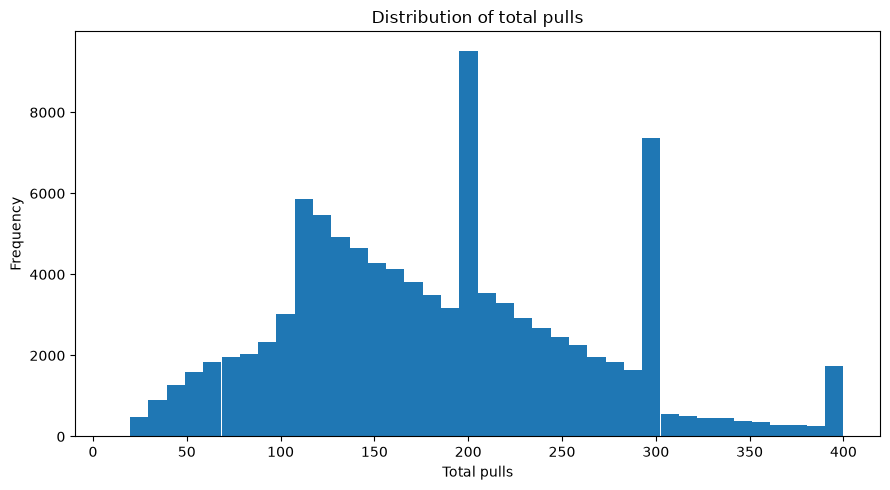

In [14]:
pull_counts = [
    result.state.pulls
    for result in results
]

plt.figure(figsize=(9, 5))
plt.hist(pull_counts, bins=40)
plt.xlabel("Total pulls")
plt.ylabel("Frequency")
plt.title("Distribution of total pulls")
plt.tight_layout()
plt.show()


## 12. 簡易テスト

In [15]:
def run_tests() -> tuple[bool, str]:
    config = Config(
        pickup_rate=1.0,
        other_pickup_rate=0.0,
        star3_rate=1.0,
        star2_or_higher_rate=1.0,
        pulls_per_batch=10,
    )

    trial = simulate_once(
        config=config,
        seed=1,
        stop_condition=stop_when_both_obtained,
        switch_condition=switch_when_pu1_obtained,
    )

    state = trial.state

    checks = (
        state.pu1_banner_pulls == 10,
        state.pu2_banner_pulls == 10,
        state.pu1 == 10,
        state.pu2 == 10,
        state.pulls == 20,
        state.batches == 2,
    )

    if all(checks):
        return True, "All tests passed."

    return False, f"Test failed: {state}"


test_ok, test_message = run_tests()
print(test_message)


All tests passed.


## 13. 独自条件の例

```python
def custom_switch(state: State) -> bool:
    return (
        state.pu1 >= 2
        or state.pu1_banner_pulls >= 150
        or state.star3 >= 8
    )


def custom_stop(state: State) -> bool:
    return (
        state.pu1 >= 1
        and state.pu2 >= 1
    ) or state.pulls >= 500
```

いずれの関数も外部変数を書き換えず、判定結果を `return` します。


## 100チャージ確定★3の仕様

100チャージ時は次の確率で抽選します。

- 対象PU：`charge_100_target_rate`
- 同時開催の別PU：`charge_100_other_pickup_rate`
- その他の★3：残り

つまり、

```python
other_star3_rate = (
    1
    - charge_100_target_rate
    - charge_100_other_pickup_rate
)
```

です。

例として、

```python
charge_100_target_rate = 0.5
charge_100_other_pickup_rate = 0.02
```

なら、対象PU 50%、別PU 2%、その他★3 48%です。


In [16]:
class FixedRandom:
    def __init__(self, value: float):
        self.value = value

    def random(self) -> float:
        return self.value


def test_charge_100_draws() -> tuple[bool, str]:
    config = Config(
        charge_100_target_rate=0.5,
        charge_100_other_pickup_rate=0.2,
    )

    base_state = State(
        pulls=99,
        batches=10,
        charge=99,
        banner=Banner.PU1,
        pu1=0,
        pu2=0,
        star3=0,
        pu1_banner_pulls=99,
        pu2_banner_pulls=0,
    )

    target = draw_one(
        config=config,
        state=base_state,
        rng=FixedRandom(0.10),
    )

    other_pickup = draw_one(
        config=config,
        state=base_state,
        rng=FixedRandom(0.60),
    )

    other_star3 = draw_one(
        config=config,
        state=base_state,
        rng=FixedRandom(0.90),
    )

    checks = (
        target is Draw.PU1,
        other_pickup is Draw.PU2,
        other_star3 is Draw.STAR3_OTHER,
    )

    if all(checks):
        return True, "All charge-100 tests passed."

    return False, (
        f"Test failed: "
        f"{target=}, "
        f"{other_pickup=}, "
        f"{other_star3=}"
    )


test_ok, test_message = test_charge_100_draws()
print(test_message)


All charge-100 tests passed.


## 新方式・旧方式の切替

`Config.system` を変更するだけで方式を切り替えられます。

### 新方式

```python
config = Config(
    system=GachaSystem.NEW,
)
```

- 100チャージ：確定★3
- 200チャージ：現在の対象PU
- 現在の対象PUを引くとチャージは0へ戻る

### 旧方式

```python
config = Config(
    system=GachaSystem.OLD,
)
```

- 各抽選は通常抽選
- 通常抽選でPUを引いてもポイントはリセットされない
- ガチャ終了時に保有ポイントをまとめて交換する
- 200ポイントごとにPUを1人交換する
- 各交換時点でPU1・PU2の所持数が少ない方を選ぶ
- PU1・PU2が同数ならPU1を選ぶ
- 交換したPUはPU人数と★3人数の両方へ加算される

交換処理は `simulate_once()` のループ終了後に1回だけ実行されます。


In [30]:
new_config = Config(
    system=GachaSystem.NEW,
    pulls_per_batch=1,
)

old_config = Config(
    system=GachaSystem.OLD,
    pulls_per_batch=1,
    old_ceiling_points=200,
)

new_results = simulate_many(
    config=new_config,
    n_simulations=1_000_000,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_both_obtained(state)
        or state.pulls >= 400
    ),
    switch_condition=switch_when_pu1_obtained,
)

old_results = simulate_many(
    config=old_config,
    n_simulations=1_000_000,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_both_obtained(state)
        or (state.pulls >= 200 and stop_when_pu1_or_pu2_obtained(state))
        or state.pulls >= 400
    ),
    switch_condition=switch_when_pu1_obtained,
)

print("新方式")
for line in format_summary(summarize(new_results)):
    print(line)

print("\n旧方式")
for line in format_summary(summarize(old_results)):
    print(line)


新方式
PU1入手率: 100.0000%
PU2入手率: 100.0000%
両方入手率: 100.0000%
平均PU1人数: 1.0194
平均PU2人数: 1.0003
平均★3人数: 6.5424
平均連数: 178.2723
平均バッチ数: 178.2723
平均PU1募集連数: 90.0110
平均PU2募集連数: 88.2614

旧方式
PU1入手率: 100.0000%
PU2入手率: 100.0000%
両方入手率: 100.0000%
平均PU1人数: 1.0155
平均PU2人数: 1.0004
平均★3人数: 6.3420
平均連数: 190.1206
平均バッチ数: 190.1206
平均PU1募集連数: 132.4847
平均PU2募集連数: 57.6358


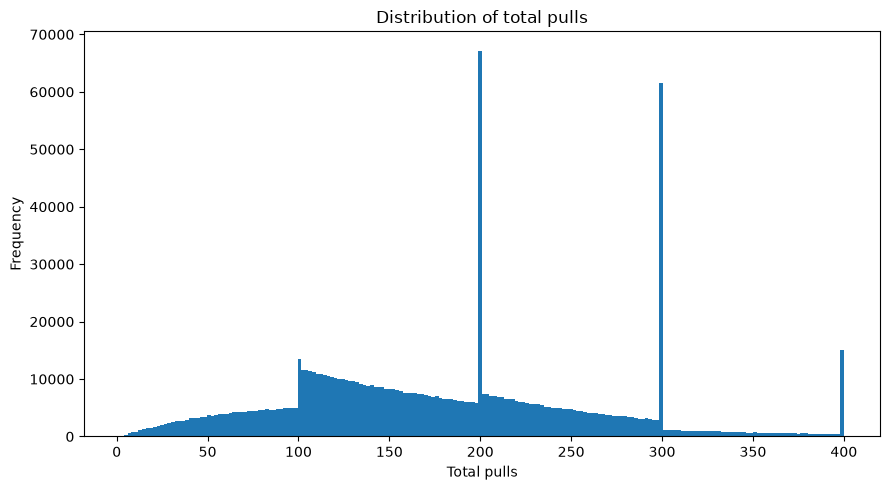

In [36]:
pull_counts = [
    result.state.pulls
    for result in new_results
]

plt.figure(figsize=(9, 5))
plt.hist(pull_counts, bins=200)
plt.xlabel("Total pulls")
plt.ylabel("Frequency")
plt.title("Distribution of total pulls")
plt.tight_layout()
plt.show()

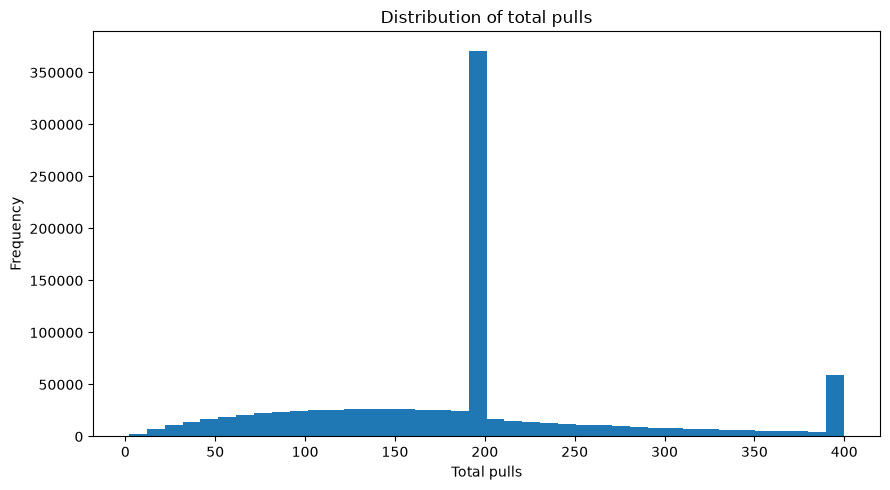

In [32]:
pull_counts = [
    result.state.pulls
    for result in old_results
]

plt.figure(figsize=(9, 5))
plt.hist(pull_counts, bins=40)
plt.xlabel("Total pulls")
plt.ylabel("Frequency")
plt.title("Distribution of total pulls")
plt.tight_layout()
plt.show()

In [40]:
old_luchey_stop_config = Config(
    system=GachaSystem.OLD,
    pulls_per_batch=1,
    old_ceiling_points=200,
)

old_luchey_stop_results = simulate_many(
    config=old_config,
    n_simulations=10_000,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_luchey(state,120)
        or stop_when_both_obtained(state)
        or state.pulls >= 200
    ),
    switch_condition=switch_when_pu1_obtained,
)

print("\n旧方式(運がいいとき撤退・120)")
for line in format_summary(summarize(old_luchey_stop_results)):
    print(line)


旧方式(運がいいとき撤退・120)
PU1入手率: 100.0000%
PU2入手率: 19.8200%
両方入手率: 19.8200%
平均PU1人数: 1.0018
平均PU2人数: 0.1984
平均★3人数: 3.8311
平均連数: 115.3646
平均バッチ数: 115.3646
平均PU1募集連数: 108.9813
平均PU2募集連数: 6.3833


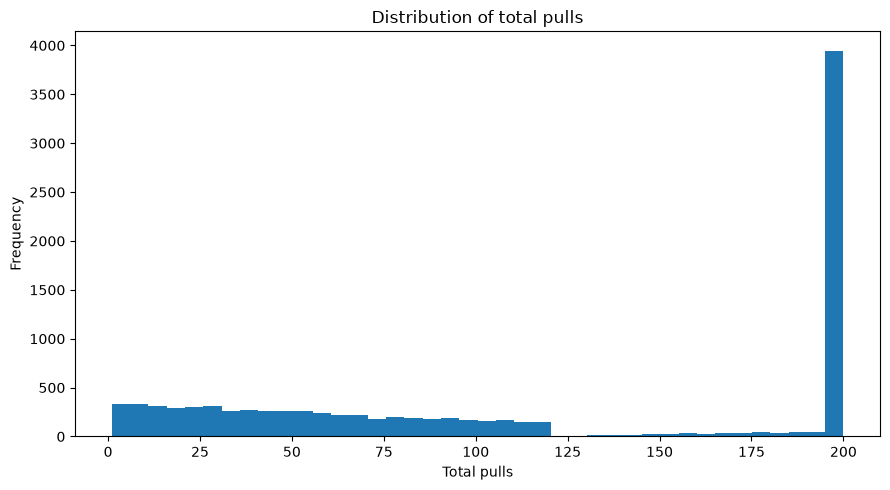

In [41]:
pull_counts = [
    result.state.pulls
    for result in old_luchey_stop_results
]

plt.figure(figsize=(9, 5))
plt.hist(pull_counts, bins=40)
plt.xlabel("Total pulls")
plt.ylabel("Frequency")
plt.title("Distribution of total pulls")
plt.tight_layout()
plt.show()

In [70]:
new_luckey_stop_config = Config(
    system=GachaSystem.NEW,
    pulls_per_batch=1,
)

new_luckey_stop_results = simulate_many(
    config=new_config,
    n_simulations=1_000_000,
    master_seed=42,
    stop_condition=lambda state: (
        stop_when_luchey(state,120)
        or stop_when_both_obtained(state)
        #or stop_when_pu2_many_draw(state,150)
        or state.pulls >= 400
    ),
    switch_condition=switch_when_pu1_obtained,
)


print("\n新方式(運がいいとき撤退・120)")
for line in format_summary(summarize(new_luckey_stop_results)):
    print(line)


新方式(運がいいとき撤退・120)
PU1入手率: 100.0000%
PU2入手率: 22.7984%
両方入手率: 22.7984%
平均PU1人数: 1.0041
平均PU2人数: 0.2282
平均★3人数: 3.9933
平均連数: 108.7932
平均バッチ数: 108.7932
平均PU1募集連数: 90.0110
平均PU2募集連数: 18.7822
平均チャージ数: 0.0000


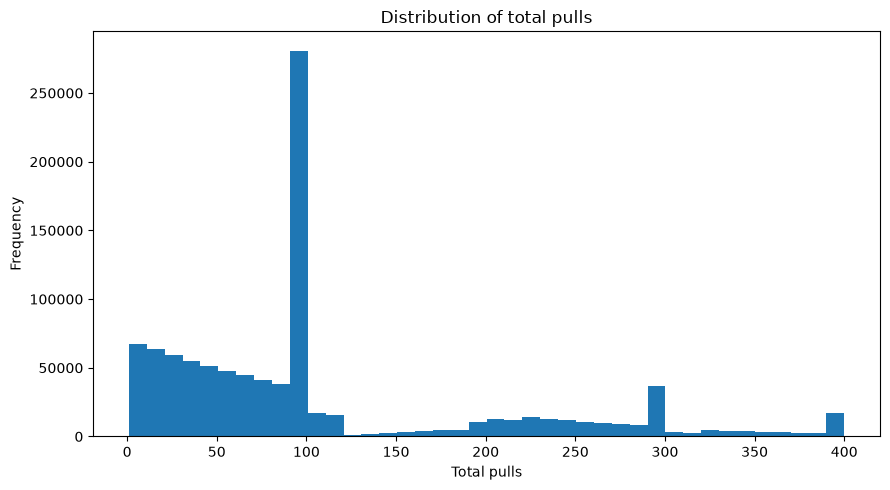

In [71]:
pull_counts = [
    result.state.pulls
    for result in new_luckey_stop_results
]

plt.figure(figsize=(9, 5))
plt.hist(pull_counts, bins=40)
plt.xlabel("Total pulls")
plt.ylabel("Frequency")
plt.title("Distribution of total pulls")
plt.tight_layout()
plt.show()

In [19]:
def test_old_system_end_exchange() -> tuple[bool, str]:
    config = Config(
        system=GachaSystem.OLD,
        pickup_rate=0.0,
        other_pickup_rate=0.0,
        star3_rate=0.0,
        star2_or_higher_rate=0.0,
        pulls_per_batch=10,
        old_ceiling_points=200,
    )

    trial = simulate_once(
        config=config,
        seed=1,
        stop_condition=lambda state: state.pulls >= 600,
        switch_condition=never_switch,
    )

    state = trial.state

    # 600ポイント -> 3回交換
    # 同数ならPU1から始めるため PU1=2, PU2=1
    checks = (
        state.pulls == 600,
        state.pu1 == 2,
        state.pu2 == 1,
        state.charge == 0,
        state.star3 == 3,
    )

    if all(checks):
        return True, "Old-system end-exchange test passed."

    return False, f"Old-system end-exchange test failed: {state}"


test_ok, test_message = test_old_system_end_exchange()
print(test_message)


Old-system end-exchange test passed.


In [20]:
def test_exchange_to_fewer_pickup() -> tuple[bool, str]:
    config = Config(
        system=GachaSystem.OLD,
        old_ceiling_points=200,
    )

    state = State(
        pulls=800,
        batches=80,
        charge=800,
        banner=Banner.PU1,
        pu1=3,
        pu2=0,
        star3=3,
        pu1_banner_pulls=400,
        pu2_banner_pulls=400,
    )

    exchanged = exchange_old_points_at_end(
        config=config,
        state=state,
    )

    # 4回交換:
    # (3,0) -> PU2 -> (3,1)
    #        -> PU2 -> (3,2)
    #        -> PU2 -> (3,3)
    # 同数なので PU1 -> (4,3)
    checks = (
        exchanged.pu1 == 4,
        exchanged.pu2 == 3,
        exchanged.charge == 0,
        exchanged.star3 == 7,
    )

    if all(checks):
        return True, "Fewer-pickup exchange test passed."

    return False, f"Fewer-pickup exchange test failed: {exchanged}"


test_ok, test_message = test_exchange_to_fewer_pickup()
print(test_message)


Fewer-pickup exchange test passed.


In [21]:
def smoke_test_draw_functions() -> tuple[bool, str]:
    config = Config(system=GachaSystem.OLD)
    state = create_initial_state(config)
    rng = random.Random(123)

    result = draw_one(
        config=config,
        state=state,
        rng=rng,
    )

    if isinstance(result, Draw):
        return True, "draw_normal / draw_one smoke test passed."

    return False, f"Unexpected result: {result}"


test_ok, test_message = smoke_test_draw_functions()
print(test_message)


draw_normal / draw_one smoke test passed.
